# init

In [1]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

class Lorentz:
    def __init__(self, s=10, r=28, b=8/3):
        self.s, self.r, self.b = s, r, b

    def X(self, x, y, s): return s * (y - x)
    def Y(self, x, y, z, r): return -x*z + r*x - y
    def Z(self, x, y, z, b): return x*y - b*z

    def RK4(self, x, y, z, s, r, b, dt):
        k1 = self.X(x, y, s)
        l1 = self.Y(x, y, z, r)
        m1 = self.Z(x, y, z, b)

        k2 = self.X(x + k1*dt/2, y + l1*dt/2, s)
        l2 = self.Y(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, r)
        m2 = self.Z(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, b)

        k3 = self.X(x + k2*dt/2, y + l2*dt/2, s)
        l3 = self.Y(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, r)
        m3 = self.Z(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, b)

        k4 = self.X(x + k3*dt, y + l3*dt, s)
        l4 = self.Y(x + k3*dt, y + l3*dt, z + m3*dt, r)
        m4 = self.Z(x + k3*dt, y + l3*dt, z + m3*dt, b)

        x += (k1 + 2*k2 + 2*k3 + k4) * dt / 6
        y += (l1 + 2*l2 + 2*l3 + l4) * dt / 6
        z += (m1 + 2*m2 + 2*m3 + m4) * dt / 6
        return x, y, z

    def generate(self, dt, steps):
        x, y, z = 1, 1, 1
        x_list = [x]
        for _ in range(steps):
            x, y, z = self.RK4(x, y, z, self.s, self.r, self.b, dt)
            x_list.append(x)
        return np.array(x_list), None, None

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    # ----------------------------------------
    # zero crossing
    # ----------------------------------------

    f['zero_crossing_rate'] = (
        np.sum(np.diff(np.sign(x)) != 0) / len(x)
    )

    # ----------------------------------------
    # Hjorth
    # ----------------------------------------

    if np.std(x) > 0:

        mobility = np.std(dx) / np.std(x)

        ddx = np.diff(dx)

        complexity = (
            np.std(ddx) / np.std(dx) / mobility
            if np.std(dx) > 0 and mobility > 0
            else 0
        )

    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    # ----------------------------------------
    # autocorrelation
    # ----------------------------------------

    if len(x) > 1:
        f['acf_lag1'] = np.corrcoef(x[:-1], x[1:])[0, 1]
    else:
        f['acf_lag1'] = 0

    return np.array(list(f.values())), list(f.keys())


# ============================================================
# DIVERGENCE FUNCTIONS
# ============================================================

def l2_distance(left, right):
    return np.linalg.norm(left - right)


def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)


def relative_change(left, right):

    eps = 1e-8

    rel = np.abs(right - left) / (np.abs(left) + eps)

    return np.mean(rel)

# start

## params

In [3]:
WINDOW = 100
STEP = 50

## data

In [20]:
dt = 0.01
skip = 1000
segments = []
change_indices = []
current_idx = 0

rs = []
points_per_segment_list = []

for i in range(100):
    r = 33 + np.random.uniform(-5, 5)
    rs.append(r)
    points_per_segment = 192000 + int(10000 * np.random.uniform(50, 100))
    points_per_segment_list.append(points_per_segment)

    lorenz = Lorentz(r=r)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip)
    x = x[skip:]
    x_norm = (x - x.min()) / (x.max() - x.min())
    segments.append(x_norm)
    if i > 0:
        change_indices.append(current_idx)
    current_idx += len(x_norm)

data = np.concatenate(segments)
print(f"Total points: {len(data)}, Changes at: {change_indices}")

Total points: 93750727, Changes at: [1109479, 1821082, 2564804, 3439259, 4231730, 5261708, 6243675, 7231865, 8260034, 8997535, 9698698, 10839573, 11544508, 12624466, 13678312, 14843652, 16035173, 16984973, 18027268, 18890485, 19890988, 20633916, 21535927, 22699772, 23410112, 24188748, 25100441, 26222029, 27021747, 27836692, 28594840, 29358905, 30256478, 30983228, 31829118, 32892047, 33810496, 35000340, 35830802, 36557083, 37655923, 38389217, 39449551, 40549074, 41636628, 42384379, 43528608, 44464317, 45213873, 46392793, 47178532, 48315843, 49133915, 50160345, 51054055, 51754414, 52802726, 53606385, 54525229, 55642926, 56572102, 57271847, 58131574, 58920276, 59687963, 60689255, 61702664, 62796559, 63773221, 64802247, 65509359, 66263579, 67279655, 68093573, 69231160, 70035057, 71069207, 71894781, 72971039, 74106518, 75178581, 76186430, 76880511, 77987822, 79060748, 80223300, 81193485, 82383697, 83502737, 84225319, 85026531, 86060408, 86820550, 87928232, 88992943, 89779365, 90566765, 9173

In [5]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

change_points = np.array(change_indices)

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [6]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

In [7]:
len(data) / len(scores_mahal)

50.00009735645139

# plot

In [8]:
change_points_in_scores = change_points_in_scores = [cp // STEP for cp in change_indices]

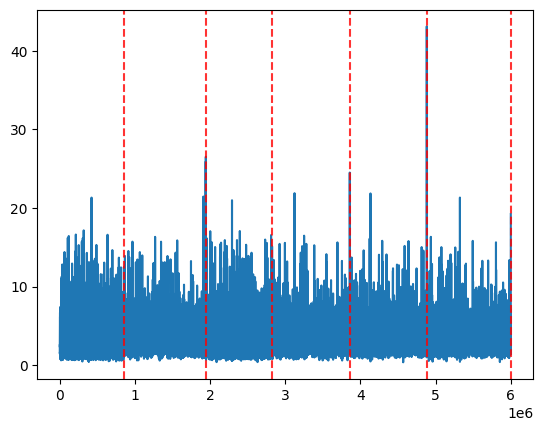

In [9]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# mean plot

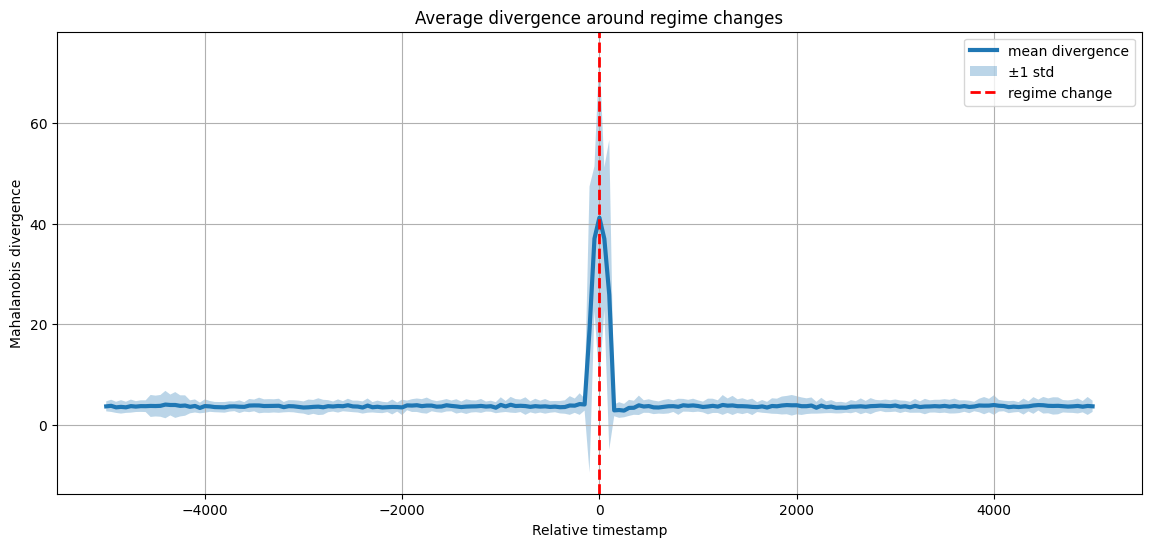

In [10]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

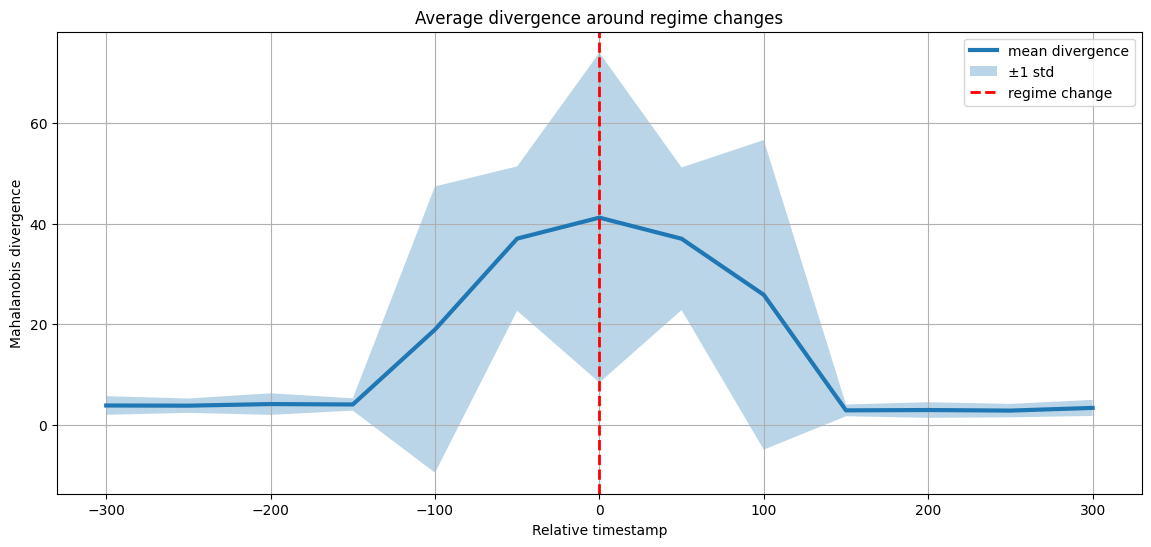

In [11]:
half_range = 300

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

# WINDOW = 100 STEP = 25

In [13]:
WINDOW = 100
STEP = 25

timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

change_points = np.array(change_indices)

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plot

### overall

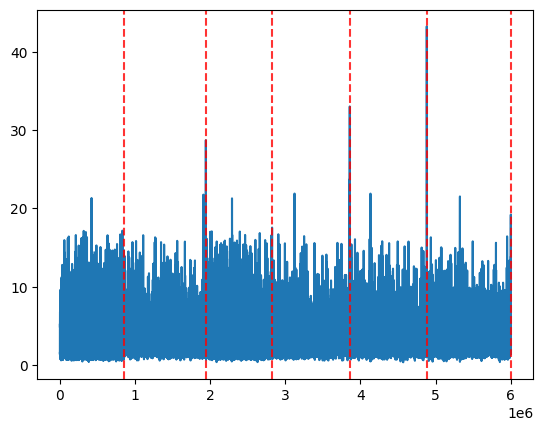

In [14]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

### large half range

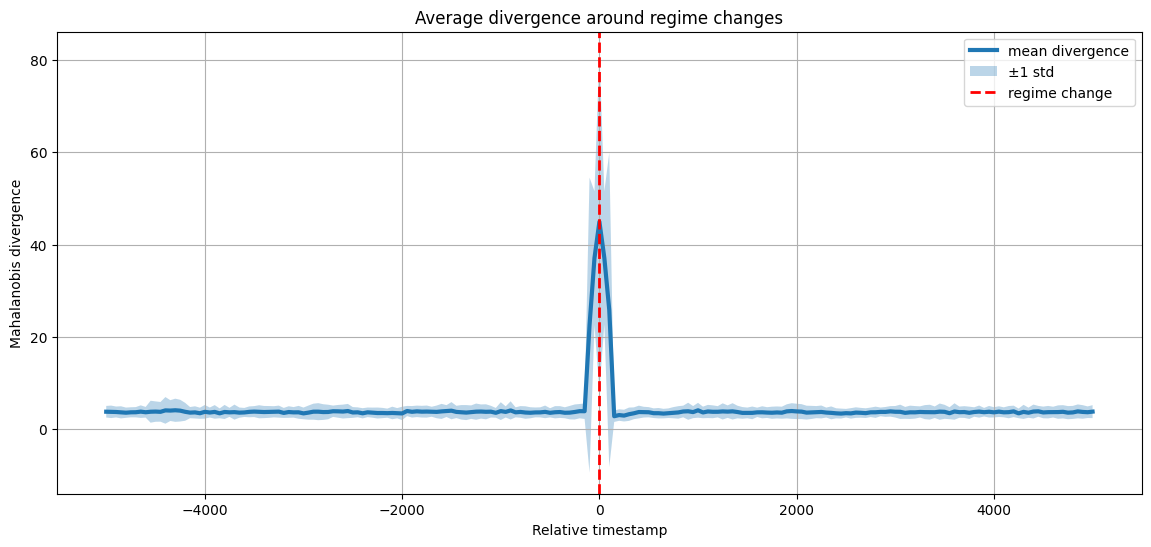

In [15]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### small half range

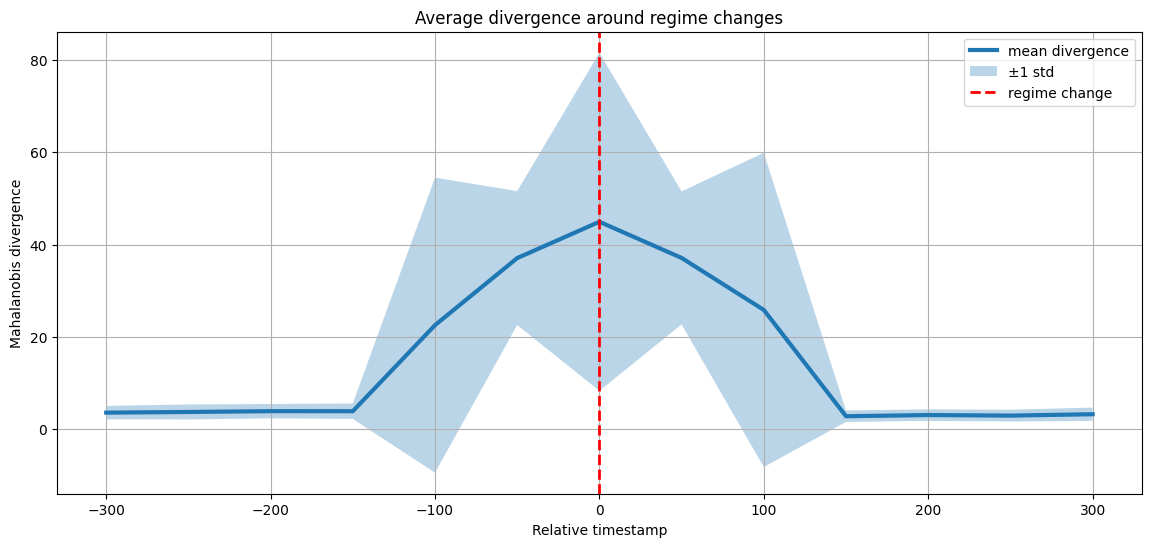

In [16]:
half_range = 300

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

# WINDOW = 25 STEP = 50

In [21]:
WINDOW = 25
STEP = 50

timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

change_points = np.array(change_indices)

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plot

### overall

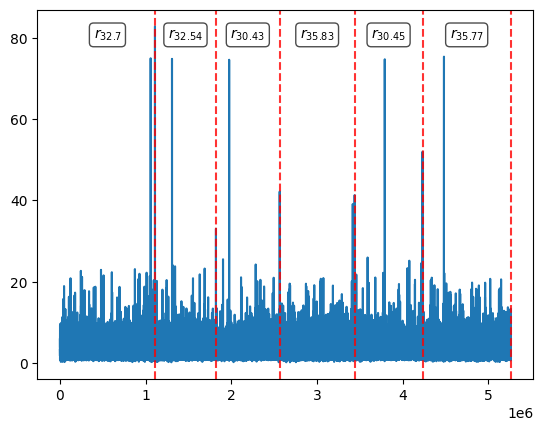

In [25]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# Add subscripts between vertical lines
# Create segment boundaries: start (before first cp) + all cps up to the 6th
boundaries = [timestamps[0]] + list(change_indices[:6])

# Add subscripts for each segment
for i in range(len(boundaries) - 1):
    # Calculate midpoint between two vertical lines
    mid_x = (boundaries[i] + boundaries[i+1]) / 2

    # Get the maximum y-value for text placement
    y_max = plt.ylim()[1]
    y_position = y_max * 0.95  # 95% of the way up

    # Add subscript text for rs and points_per_segment
    plt.text(mid_x, y_position,
             f'$r_{{{np.round(rs[i], 2)}}}$',
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

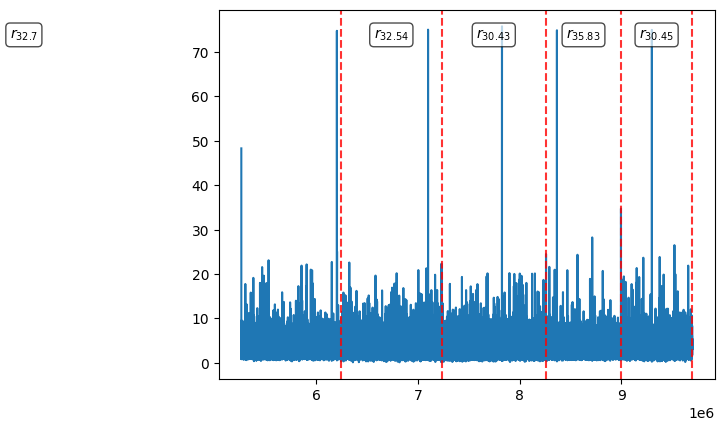

In [26]:
plt.plot(
    timestamps[(timestamps > change_indices[5]) & (timestamps < change_indices[10])],
    scores_mahal[(timestamps > change_indices[5]) & (timestamps < change_indices[10])],
)

# Plot vertical lines for change points
for cp in change_indices[6:11]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# Add subscripts between vertical lines
# Create segment boundaries: start (before first cp) + all cps up to the 6th
boundaries = [timestamps[5]] + list(change_indices[6:11])

# Add subscripts for each segment
for i in range(len(boundaries) - 1):
    # Calculate midpoint between two vertical lines
    mid_x = (boundaries[i] + boundaries[i+1]) / 2

    # Get the maximum y-value for text placement
    y_max = plt.ylim()[1]
    y_position = y_max * 0.95  # 95% of the way up

    # Add subscript text for rs and points_per_segment
    plt.text(mid_x, y_position,
             f'$r_{{{np.round(rs[i], 2)}}}$',
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

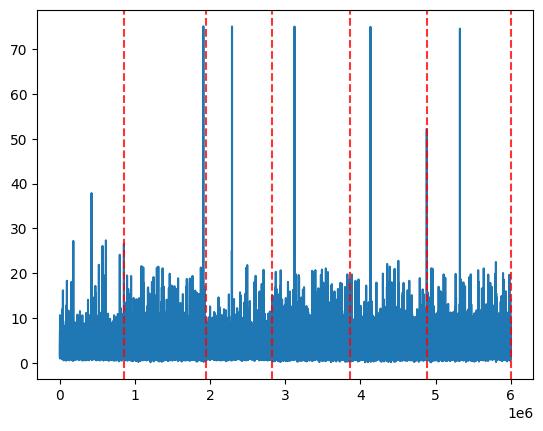

In [19]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# w=100 s=100

In [27]:
WINDOW = 100
STEP = 100

timestamps = []
scores_mahal = []

change_points = np.array(change_indices)

# collect all feature vectors first, covariance for Mahalanobis must be over full feature space
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    timestamps.append(t)

    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

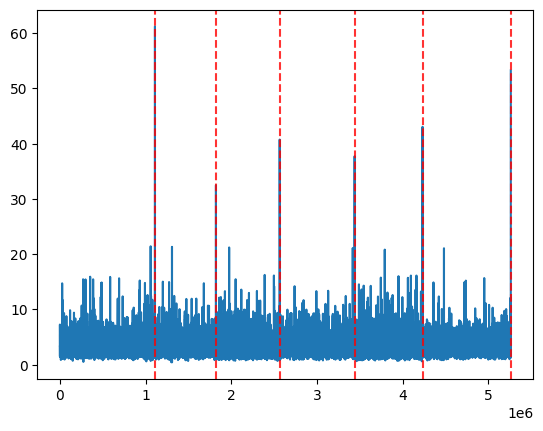

In [28]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# # Add subscripts between vertical lines
# # Create segment boundaries: start (before first cp) + all cps up to the 6th
# boundaries = [timestamps[0]] + list(change_indices[:6])
#
# # Add subscripts for each segment
# for i in range(len(boundaries) - 1):
#     # Calculate midpoint between two vertical lines
#     mid_x = (boundaries[i] + boundaries[i+1]) / 2
#
#     # Get the maximum y-value for text placement
#     y_max = plt.ylim()[1]
#     y_position = y_max * 0.95  # 95% of the way up
#
#     # Add subscript text for rs and points_per_segment
#     plt.text(mid_x, y_position,
#              f'$r_{{{np.round(rs[i], 2)}}}$',
#              ha='center', va='top',
#              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

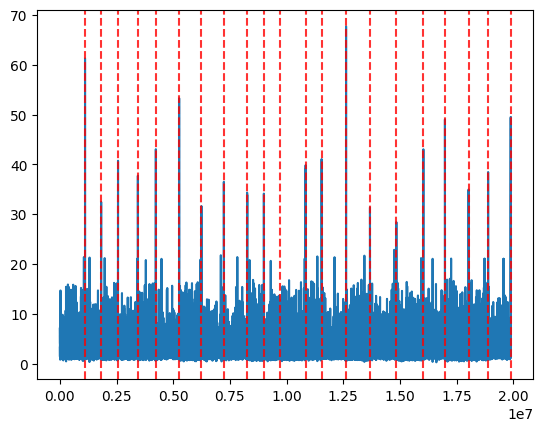

In [29]:
plt.plot(
    timestamps[timestamps < change_indices[20]],
    scores_mahal[timestamps < change_indices[20]],
)

# Plot vertical lines for change points
for cp in change_indices[:21]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# smaller feature set, better pipeline, w=100, s=100

In [30]:
def extract_features_new(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    # ----------------------------------------
    # zero crossing
    # ----------------------------------------

    f['zero_crossing_rate'] = (
        np.sum(np.diff(np.sign(x)) != 0) / len(x)
    )

    # ----------------------------------------
    # Hjorth
    # ----------------------------------------

    if np.std(x) > 0:

        mobility = np.std(dx) / np.std(x)

        ddx = np.diff(dx)

        complexity = (
            np.std(ddx) / np.std(dx) / mobility
            if np.std(dx) > 0 and mobility > 0
            else 0
        )

    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    return np.array(list(f.values())), list(f.keys())

In [32]:
WINDOW = 100
STEP = 100

timestamps = []
scores_mahal = []
all_features = []
feature_pairs = []  # Store which windows were compared

# First pass: Extract and store all features
window_features = []  # Store features for each window position
window_times = []

for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features_new(left_window)
    right_feat, _ = extract_features_new(right_window)

    # Store features
    window_features.append({
        'timestamp': t,
        'left_features': left_feat,
        'right_features': right_feat
    })

    # Collect for covariance matrix (all unique windows)
    all_features.append(left_feat)
    all_features.append(right_feat)

    # Store which features are paired together
    feature_pairs.append((len(window_features)-1, 'left', 'right'))

window_features = np.array(window_features, dtype=object)  # Keep as structured array
all_features = np.array(all_features)

# Compute covariance matrix (once)
cov = np.cov(all_features.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = pinv(cov)

# Second pass: Compute distances using precomputed features
timestamps = []
scores_mahal = []

for idx, pair in enumerate(window_features):
    left_feat = pair['left_features']
    right_feat = pair['right_features']
    t = pair['timestamp']

    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

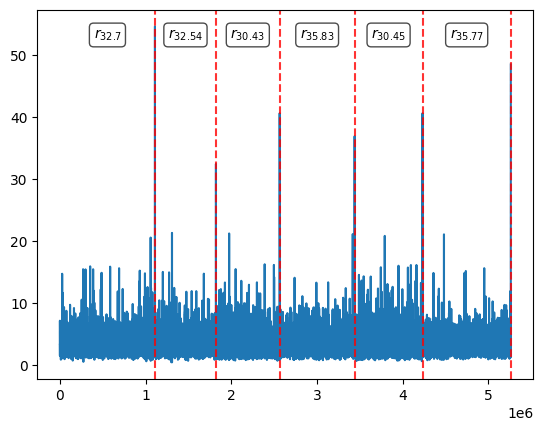

In [33]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# Add subscripts between vertical lines
# Create segment boundaries: start (before first cp) + all cps up to the 6th
boundaries = [timestamps[0]] + list(change_indices[:6])

# Add subscripts for each segment
for i in range(len(boundaries) - 1):
    # Calculate midpoint between two vertical lines
    mid_x = (boundaries[i] + boundaries[i+1]) / 2

    # Get the maximum y-value for text placement
    y_max = plt.ylim()[1]
    y_position = y_max * 0.95  # 95% of the way up

    # Add subscript text for rs and points_per_segment
    plt.text(mid_x, y_position,
             f'$r_{{{np.round(rs[i], 2)}}}$',
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

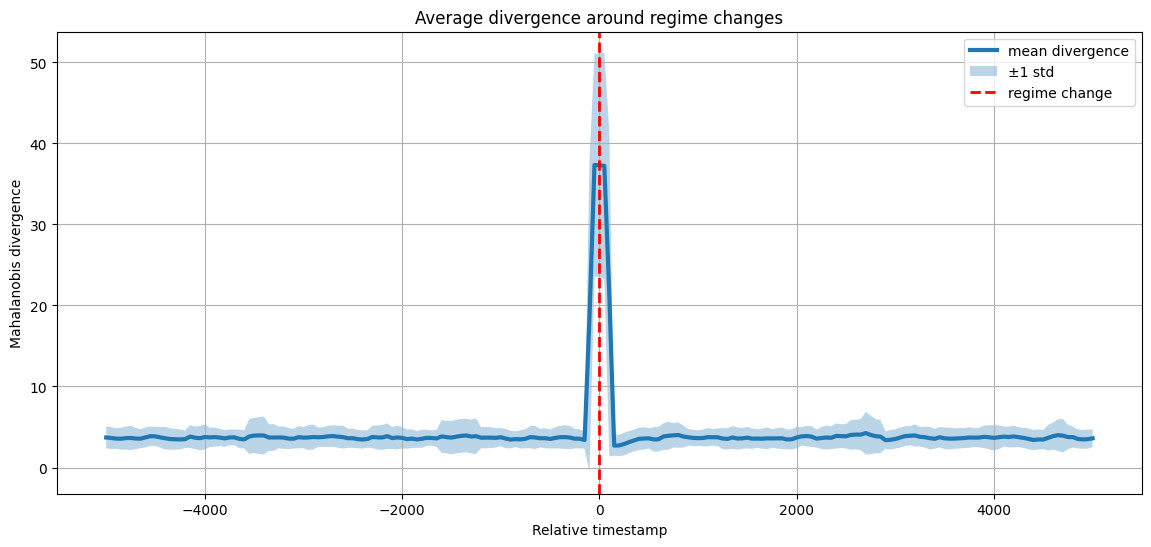

In [34]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

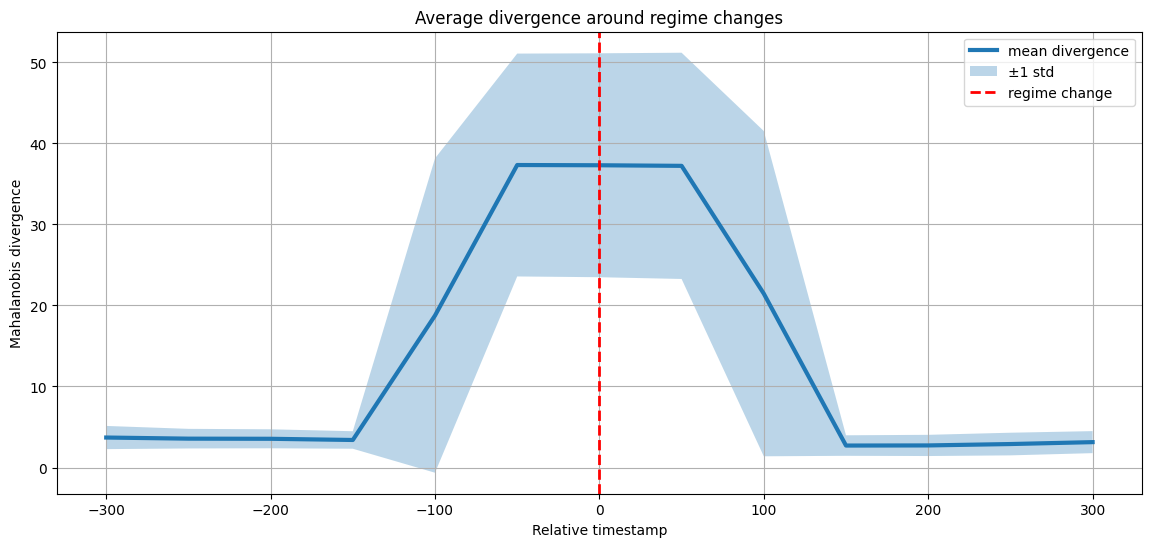

In [35]:
half_range = 300

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

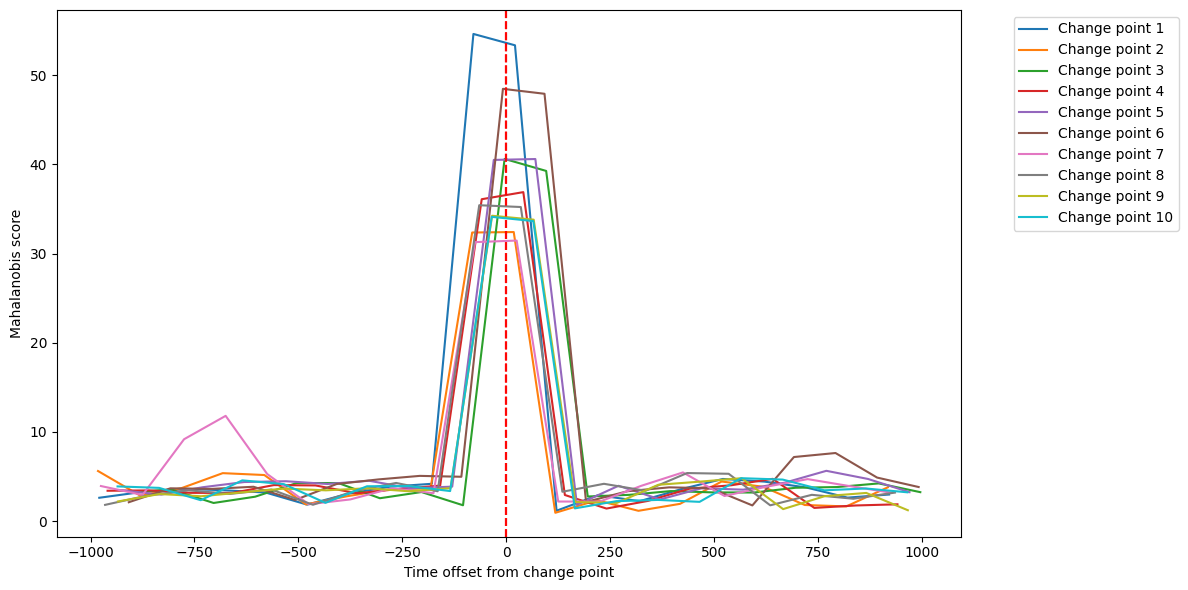

In [43]:
plt.figure(figsize=(12, 6))

for i in range(10):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores_mahal[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

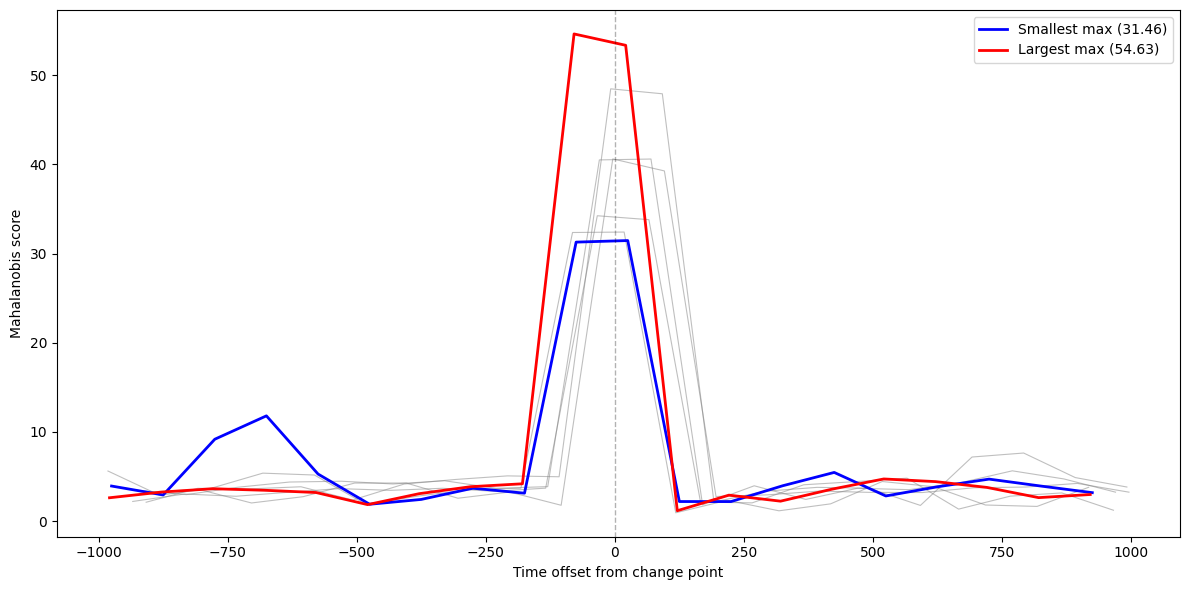

In [45]:
import numpy as np

plt.figure(figsize=(12, 6))

# Calculate the maximum value for each segment
max_values = []
for i in range(10):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    scores = scores_mahal[mask]
    max_values.append(np.max(scores))

# Find indices with smallest and largest maximum
min_max_idx = np.argmin(max_values)  # smallest of the biggest
max_max_idx = np.argmax(max_values)  # largest of the biggest

# Get remaining indices and select 5 random ones
remaining_indices = [i for i in range(10) if i not in [min_max_idx, max_max_idx]]
random_indices = np.random.choice(remaining_indices, 5, replace=False)

# Plot random gray segments
for i in random_indices:
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]
    plt.plot(relative_time, scores_mahal[mask], color='gray', alpha=0.5, linewidth=0.8)

# Plot blue line (smallest maximum)
mask_blue = (timestamps > change_indices[min_max_idx] - 1000) & (timestamps < change_indices[min_max_idx] + 1000)
relative_time_blue = timestamps[mask_blue] - change_indices[min_max_idx]
plt.plot(relative_time_blue, scores_mahal[mask_blue], color='blue', linewidth=2, label=f'Smallest max ({max_values[min_max_idx]:.2f})')

# Plot red line (largest maximum)
mask_red = (timestamps > change_indices[max_max_idx] - 1000) & (timestamps < change_indices[max_max_idx] + 1000)
relative_time_red = timestamps[mask_red] - change_indices[max_max_idx]
plt.plot(relative_time_red, scores_mahal[mask_red], color='red', linewidth=2, label=f'Largest max ({max_values[max_max_idx]:.2f})')

plt.axvline(0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend()
plt.tight_layout()
plt.show()

# only statistical features (bad)

In [46]:
def extract_features_new_v2(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    return np.array(list(f.values())), list(f.keys())

In [47]:
WINDOW = 100
STEP = 100

timestamps = []
scores_mahal = []
all_features = []
feature_pairs = []  # Store which windows were compared

# First pass: Extract and store all features
window_features = []  # Store features for each window position
window_times = []

for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features_new_v2(left_window)
    right_feat, _ = extract_features_new_v2(right_window)

    # Store features
    window_features.append({
        'timestamp': t,
        'left_features': left_feat,
        'right_features': right_feat
    })

    # Collect for covariance matrix (all unique windows)
    all_features.append(left_feat)
    all_features.append(right_feat)

    # Store which features are paired together
    feature_pairs.append((len(window_features)-1, 'left', 'right'))

window_features = np.array(window_features, dtype=object)  # Keep as structured array
all_features = np.array(all_features)

# Compute covariance matrix (once)
cov = np.cov(all_features.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = pinv(cov)

# Second pass: Compute distances using precomputed features
timestamps = []
scores_mahal = []

for idx, pair in enumerate(window_features):
    left_feat = pair['left_features']
    right_feat = pair['right_features']
    t = pair['timestamp']

    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

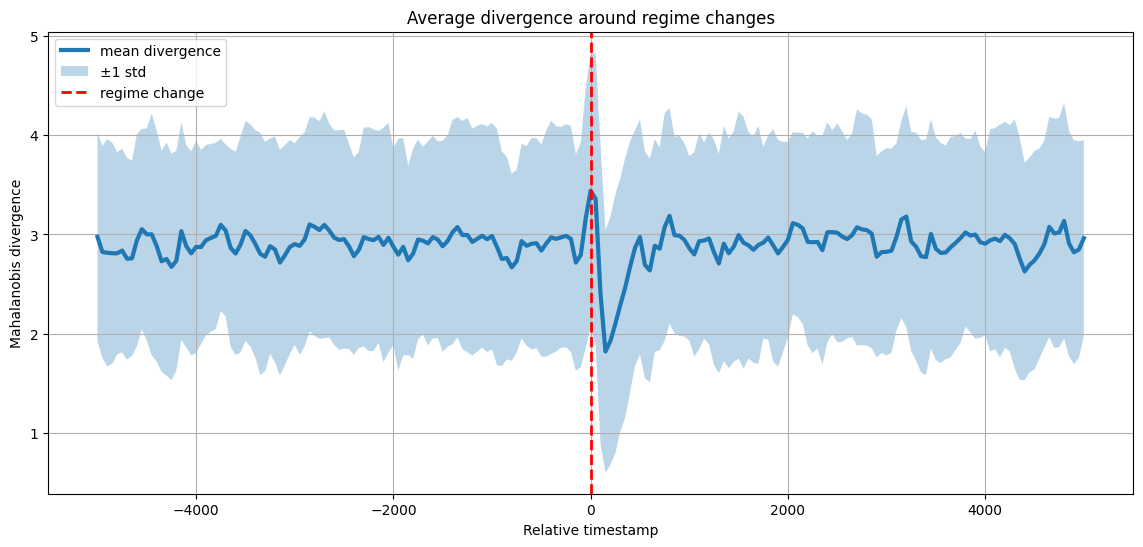

In [48]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

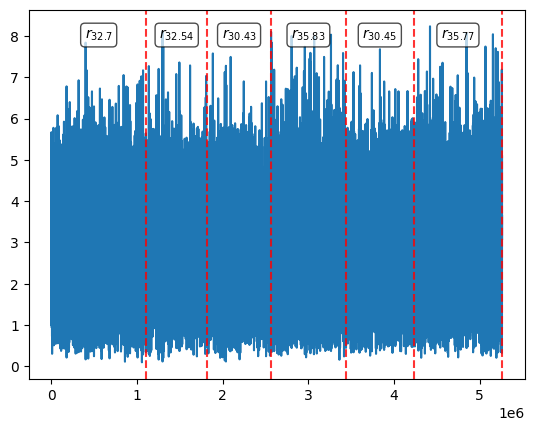

In [49]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# Add subscripts between vertical lines
# Create segment boundaries: start (before first cp) + all cps up to the 6th
boundaries = [timestamps[0]] + list(change_indices[:6])

# Add subscripts for each segment
for i in range(len(boundaries) - 1):
    # Calculate midpoint between two vertical lines
    mid_x = (boundaries[i] + boundaries[i+1]) / 2

    # Get the maximum y-value for text placement
    y_max = plt.ylim()[1]
    y_position = y_max * 0.95  # 95% of the way up

    # Add subscript text for rs and points_per_segment
    plt.text(mid_x, y_position,
             f'$r_{{{np.round(rs[i], 2)}}}$',
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# readded shape features and ptp (bad)

In [50]:
def extract_features_new_v3(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    return np.array(list(f.values())), list(f.keys())

In [51]:
WINDOW = 100
STEP = 100

timestamps = []
scores_mahal = []
all_features = []
feature_pairs = []  # Store which windows were compared

# First pass: Extract and store all features
window_features = []  # Store features for each window position
window_times = []

for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features_new_v3(left_window)
    right_feat, _ = extract_features_new_v3(right_window)

    # Store features
    window_features.append({
        'timestamp': t,
        'left_features': left_feat,
        'right_features': right_feat
    })

    # Collect for covariance matrix (all unique windows)
    all_features.append(left_feat)
    all_features.append(right_feat)

    # Store which features are paired together
    feature_pairs.append((len(window_features)-1, 'left', 'right'))

window_features = np.array(window_features, dtype=object)  # Keep as structured array
all_features = np.array(all_features)

# Compute covariance matrix (once)
cov = np.cov(all_features.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = pinv(cov)

# Second pass: Compute distances using precomputed features
timestamps = []
scores_mahal = []

for idx, pair in enumerate(window_features):
    left_feat = pair['left_features']
    right_feat = pair['right_features']
    t = pair['timestamp']

    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

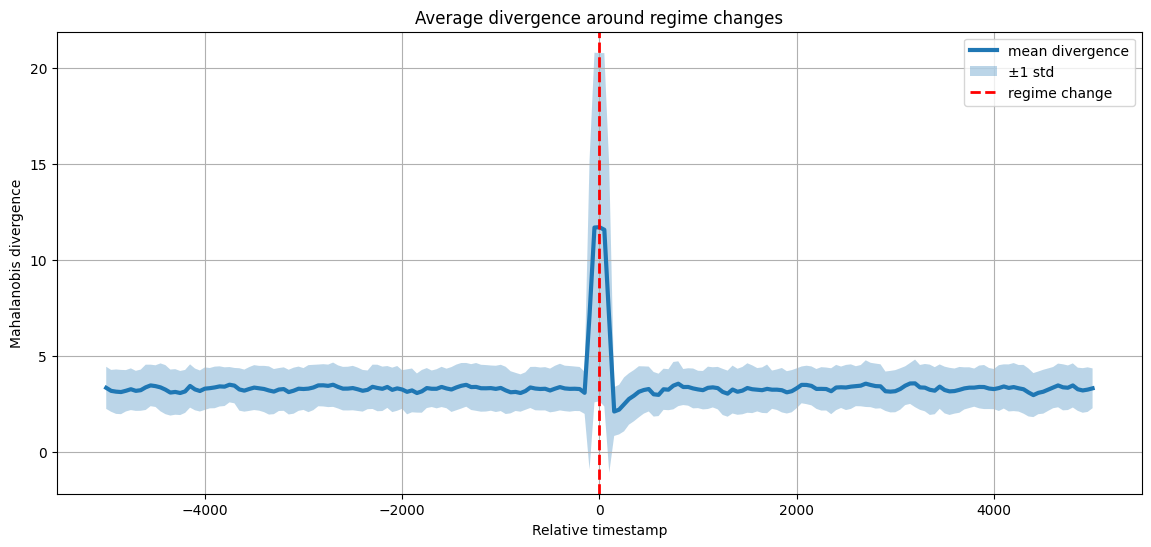

In [52]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

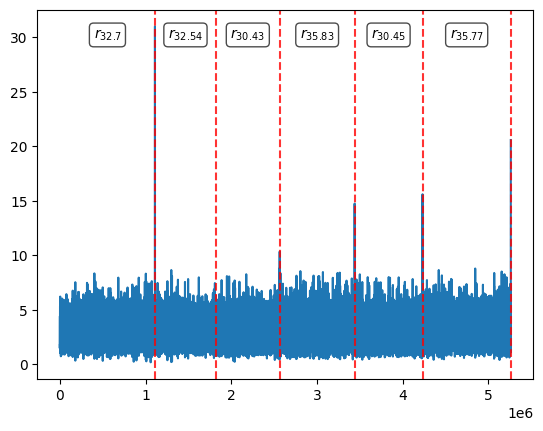

In [53]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# Add subscripts between vertical lines
# Create segment boundaries: start (before first cp) + all cps up to the 6th
boundaries = [timestamps[0]] + list(change_indices[:6])

# Add subscripts for each segment
for i in range(len(boundaries) - 1):
    # Calculate midpoint between two vertical lines
    mid_x = (boundaries[i] + boundaries[i+1]) / 2

    # Get the maximum y-value for text placement
    y_max = plt.ylim()[1]
    y_position = y_max * 0.95  # 95% of the way up

    # Add subscript text for rs and points_per_segment
    plt.text(mid_x, y_position,
             f'$r_{{{np.round(rs[i], 2)}}}$',
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

вторую полностью пропустили

# zero crossing readded (bad)

In [54]:
def extract_features_new_v4(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    f['zero_crossing_rate'] = (
        np.sum(np.diff(np.sign(x)) != 0) / len(x)
    )

    return np.array(list(f.values())), list(f.keys())

In [55]:
WINDOW = 100
STEP = 100

timestamps = []
scores_mahal = []
all_features = []
feature_pairs = []  # Store which windows were compared

# First pass: Extract and store all features
window_features = []  # Store features for each window position
window_times = []

for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features_new_v4(left_window)
    right_feat, _ = extract_features_new_v4(right_window)

    # Store features
    window_features.append({
        'timestamp': t,
        'left_features': left_feat,
        'right_features': right_feat
    })

    # Collect for covariance matrix (all unique windows)
    all_features.append(left_feat)
    all_features.append(right_feat)

    # Store which features are paired together
    feature_pairs.append((len(window_features)-1, 'left', 'right'))

window_features = np.array(window_features, dtype=object)  # Keep as structured array
all_features = np.array(all_features)

# Compute covariance matrix (once)
cov = np.cov(all_features.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = pinv(cov)

# Second pass: Compute distances using precomputed features
timestamps = []
scores_mahal = []

for idx, pair in enumerate(window_features):
    left_feat = pair['left_features']
    right_feat = pair['right_features']
    t = pair['timestamp']

    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

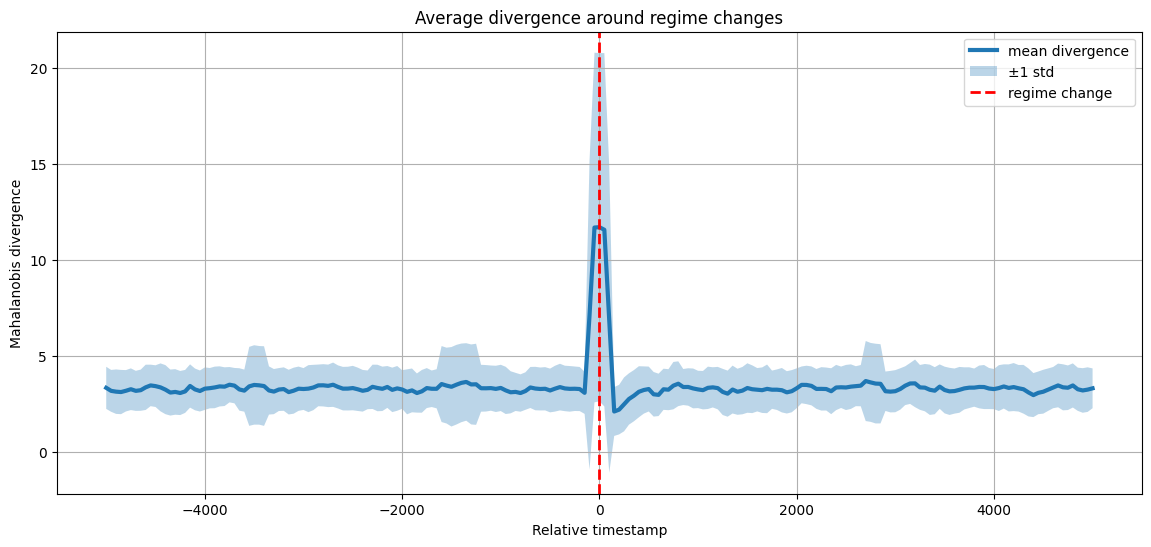

In [56]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

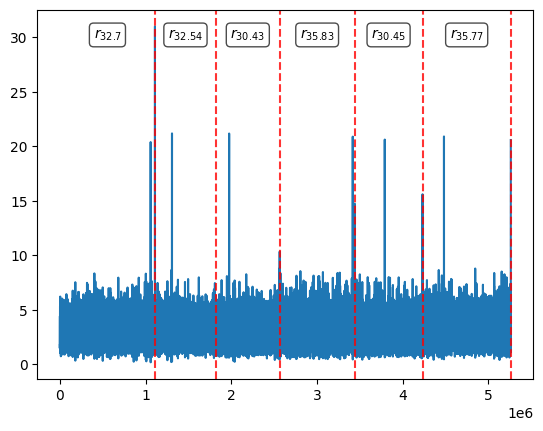

In [57]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# Add subscripts between vertical lines
# Create segment boundaries: start (before first cp) + all cps up to the 6th
boundaries = [timestamps[0]] + list(change_indices[:6])

# Add subscripts for each segment
for i in range(len(boundaries) - 1):
    # Calculate midpoint between two vertical lines
    mid_x = (boundaries[i] + boundaries[i+1]) / 2

    # Get the maximum y-value for text placement
    y_max = plt.ylim()[1]
    y_position = y_max * 0.95  # 95% of the way up

    # Add subscript text for rs and points_per_segment
    plt.text(mid_x, y_position,
             f'$r_{{{np.round(rs[i], 2)}}}$',
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# only hjorth and var + std (almost identical to the original)

In [58]:
def extract_features_new_v5(x):

    f = {}

    f['std'] = np.std(x)
    f['var'] = np.var(x)

    dx = np.diff(x)

    if np.std(x) > 0:

        mobility = np.std(dx) / np.std(x)

        ddx = np.diff(dx)

        complexity = (
            np.std(ddx) / np.std(dx) / mobility
            if np.std(dx) > 0 and mobility > 0
            else 0
        )

    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    return np.array(list(f.values())), list(f.keys())

In [59]:
WINDOW = 100
STEP = 100

timestamps = []
scores_mahal = []
all_features = []
feature_pairs = []  # Store which windows were compared

# First pass: Extract and store all features
window_features = []  # Store features for each window position
window_times = []

for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features_new_v5(left_window)
    right_feat, _ = extract_features_new_v5(right_window)

    # Store features
    window_features.append({
        'timestamp': t,
        'left_features': left_feat,
        'right_features': right_feat
    })

    # Collect for covariance matrix (all unique windows)
    all_features.append(left_feat)
    all_features.append(right_feat)

    # Store which features are paired together
    feature_pairs.append((len(window_features)-1, 'left', 'right'))

window_features = np.array(window_features, dtype=object)  # Keep as structured array
all_features = np.array(all_features)

# Compute covariance matrix (once)
cov = np.cov(all_features.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = pinv(cov)

# Second pass: Compute distances using precomputed features
timestamps = []
scores_mahal = []

for idx, pair in enumerate(window_features):
    left_feat = pair['left_features']
    right_feat = pair['right_features']
    t = pair['timestamp']

    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

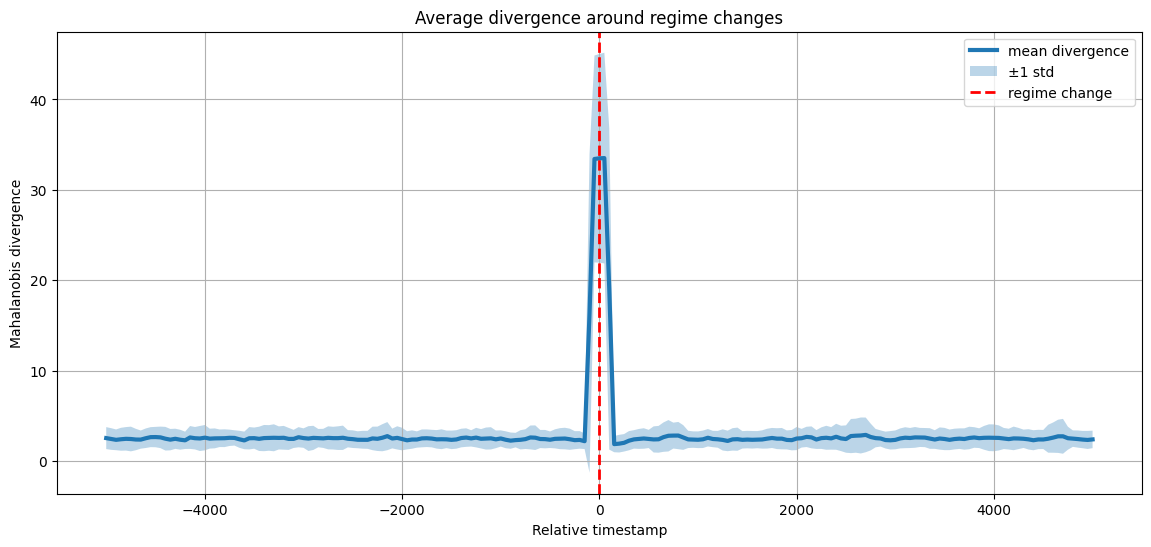

In [60]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

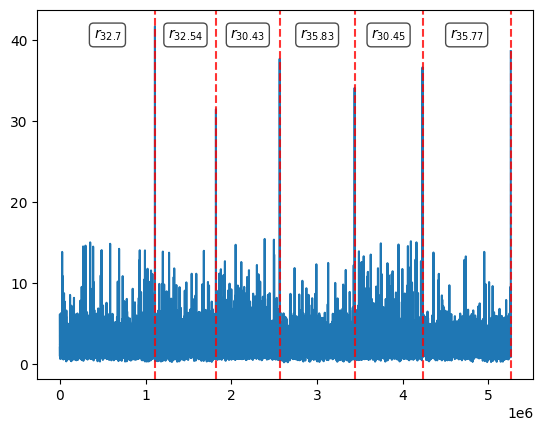

In [61]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# Add subscripts between vertical lines
# Create segment boundaries: start (before first cp) + all cps up to the 6th
boundaries = [timestamps[0]] + list(change_indices[:6])

# Add subscripts for each segment
for i in range(len(boundaries) - 1):
    # Calculate midpoint between two vertical lines
    mid_x = (boundaries[i] + boundaries[i+1]) / 2

    # Get the maximum y-value for text placement
    y_max = plt.ylim()[1]
    y_position = y_max * 0.95  # 95% of the way up

    # Add subscript text for rs and points_per_segment
    plt.text(mid_x, y_position,
             f'$r_{{{np.round(rs[i], 2)}}}$',
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

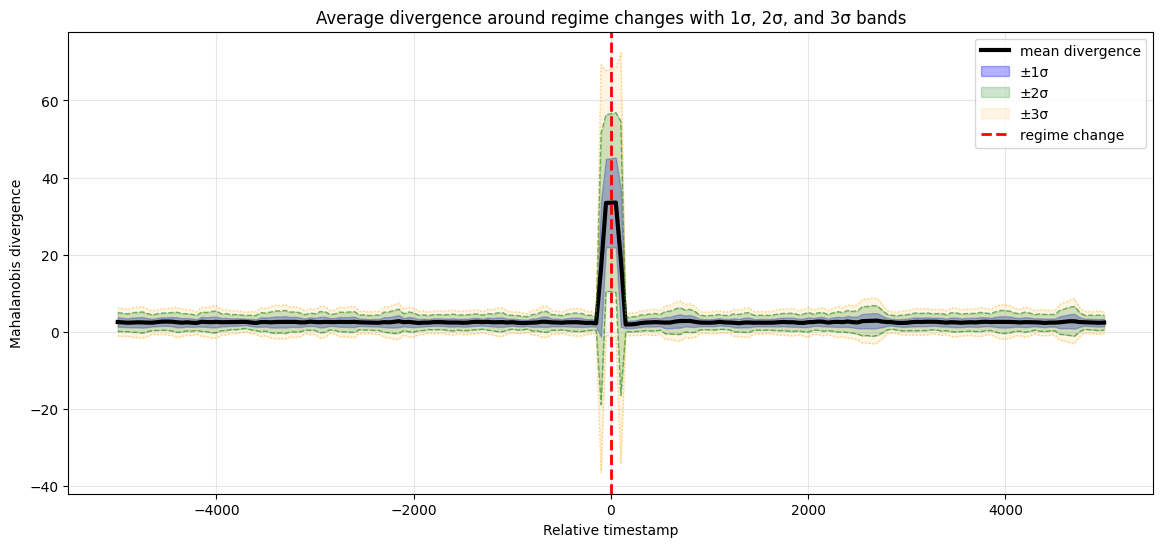

In [62]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN WITH 1σ, 2σ, AND 3σ
# ============================================================

plt.figure(figsize=(14, 6))

# Plot mean curve
plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    color='black',
    label='mean divergence'
)

# Fill between for different sigma levels
plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    color='blue',
    label='±1σ'
)

plt.fill_between(
    relative_axis,
    mean_curve - 2*std_curve,
    mean_curve + 2*std_curve,
    alpha=0.2,
    color='green',
    label='±2σ'
)

plt.fill_between(
    relative_axis,
    mean_curve - 3*std_curve,
    mean_curve + 3*std_curve,
    alpha=0.1,
    color='orange',
    label='±3σ'
)

# Plot the ±2σ and ±3σ boundaries as dashed lines (optional)
plt.plot(
    relative_axis,
    mean_curve + 2*std_curve,
    color='green',
    linestyle='--',
    linewidth=1,
    alpha=0.5
)
plt.plot(
    relative_axis,
    mean_curve - 2*std_curve,
    color='green',
    linestyle='--',
    linewidth=1,
    alpha=0.5
)

plt.plot(
    relative_axis,
    mean_curve + 3*std_curve,
    color='orange',
    linestyle=':',
    linewidth=1,
    alpha=0.5
)
plt.plot(
    relative_axis,
    mean_curve - 3*std_curve,
    color='orange',
    linestyle=':',
    linewidth=1,
    alpha=0.5
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes with 1σ, 2σ, and 3σ bands')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# introduce non-even points

In [63]:
dt = 0.01
skip = 1000
segments = []
change_indices = []
current_idx = 0

rs = []
points_per_segment_list = []

for i in range(100):
    r = 33 + np.random.uniform(-5, 5)
    rs.append(r)
    points_per_segment = 192000 + int(10000 * np.random.uniform(50, 100)) + np.random.randint(0, 99)
    points_per_segment_list.append(points_per_segment)

    lorenz = Lorentz(r=r)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip)
    x = x[skip:]
    x_norm = (x - x.min()) / (x.max() - x.min())
    segments.append(x_norm)
    if i > 0:
        change_indices.append(current_idx)
    current_idx += len(x_norm)

data = np.concatenate(segments)
print(f"Total points: {len(data)}, Changes at: {change_indices}")

Total points: 95873808, Changes at: [1019481, 2140427, 3262907, 4319482, 5175037, 6108263, 6939272, 7646691, 8790667, 9742083, 10661759, 11459267, 12288219, 13010588, 13869777, 15030800, 15950026, 17079077, 17999736, 18765191, 19935186, 20885473, 21772233, 22621718, 23654751, 24655332, 25434258, 26520334, 27614748, 28605651, 29355627, 30297860, 31180938, 31939064, 32832570, 33901199, 34865479, 35858713, 37043053, 37750201, 38608565, 39447679, 40633133, 41498936, 42278899, 43138498, 44236037, 45053164, 46159548, 46926142, 48021655, 48985187, 49766084, 50872229, 51858161, 52654449, 53382030, 54245557, 55211711, 56143416, 56939469, 58046930, 58916551, 59763587, 60522658, 61660427, 62778477, 63893720, 64963699, 65841756, 66971893, 67869918, 69037573, 70205115, 71129105, 71915464, 72867664, 73941569, 75042339, 76232456, 77260625, 78237462, 79267387, 80303111, 81402263, 82354219, 83472004, 84474762, 85460240, 86226431, 87325052, 88421162, 89286518, 90319440, 91491475, 92351742, 93499887, 942

In [64]:
WINDOW = 100
STEP = 100

timestamps = []
scores_mahal = []
all_features = []
feature_pairs = []  # Store which windows were compared

# First pass: Extract and store all features
window_features = []  # Store features for each window position
window_times = []

for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features_new_v5(left_window)
    right_feat, _ = extract_features_new_v5(right_window)

    # Store features
    window_features.append({
        'timestamp': t,
        'left_features': left_feat,
        'right_features': right_feat
    })

    # Collect for covariance matrix (all unique windows)
    all_features.append(left_feat)
    all_features.append(right_feat)

    # Store which features are paired together
    feature_pairs.append((len(window_features)-1, 'left', 'right'))

window_features = np.array(window_features, dtype=object)  # Keep as structured array
all_features = np.array(all_features)

# Compute covariance matrix (once)
cov = np.cov(all_features.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = pinv(cov)

# Second pass: Compute distances using precomputed features
timestamps = []
scores_mahal = []

for idx, pair in enumerate(window_features):
    left_feat = pair['left_features']
    right_feat = pair['right_features']
    t = pair['timestamp']

    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

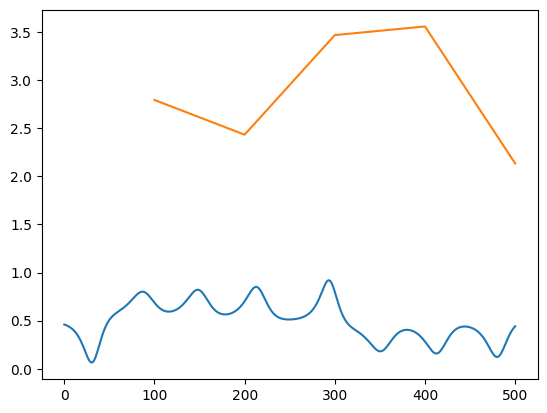

In [69]:
plt.plot(data[:501])
plt.plot(timestamps[timestamps < 501], scores_mahal[timestamps < 501])

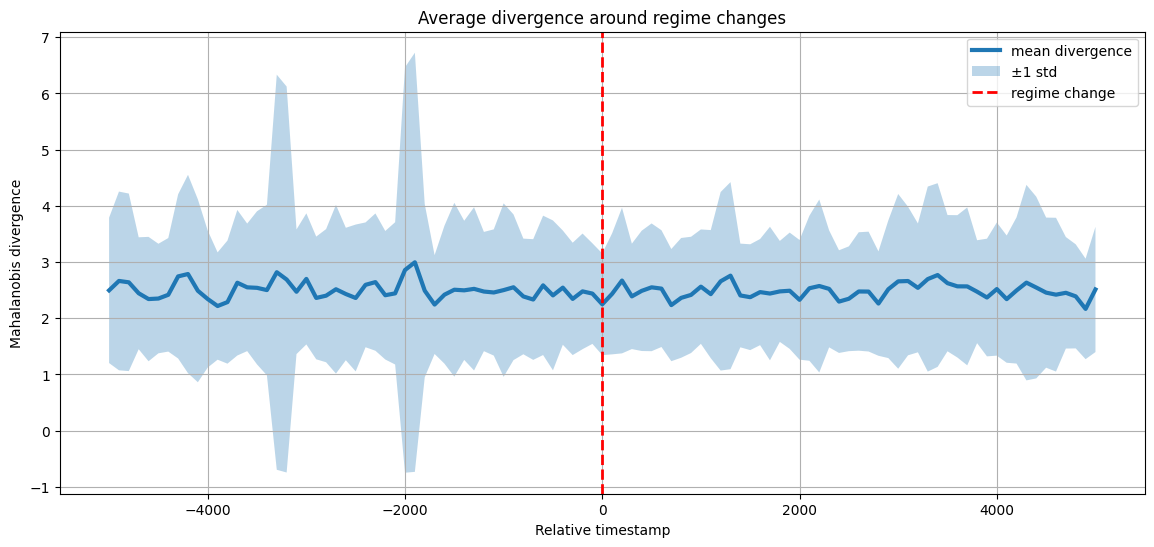

In [65]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, STEP)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

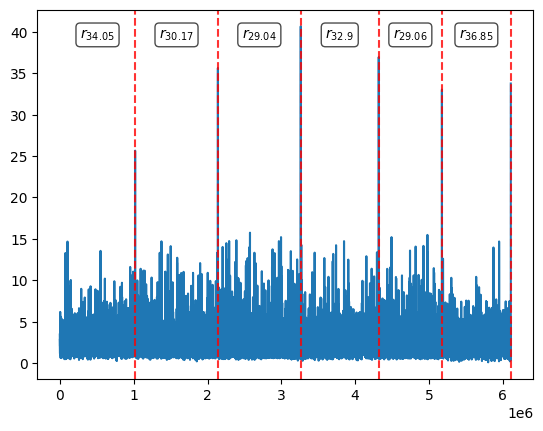

In [70]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# Add subscripts between vertical lines
# Create segment boundaries: start (before first cp) + all cps up to the 6th
boundaries = [timestamps[0]] + list(change_indices[:6])

# Add subscripts for each segment
for i in range(len(boundaries) - 1):
    # Calculate midpoint between two vertical lines
    mid_x = (boundaries[i] + boundaries[i+1]) / 2

    # Get the maximum y-value for text placement
    y_max = plt.ylim()[1]
    y_position = y_max * 0.95  # 95% of the way up

    # Add subscript text for rs and points_per_segment
    plt.text(mid_x, y_position,
             f'$r_{{{np.round(rs[i], 2)}}}$',
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

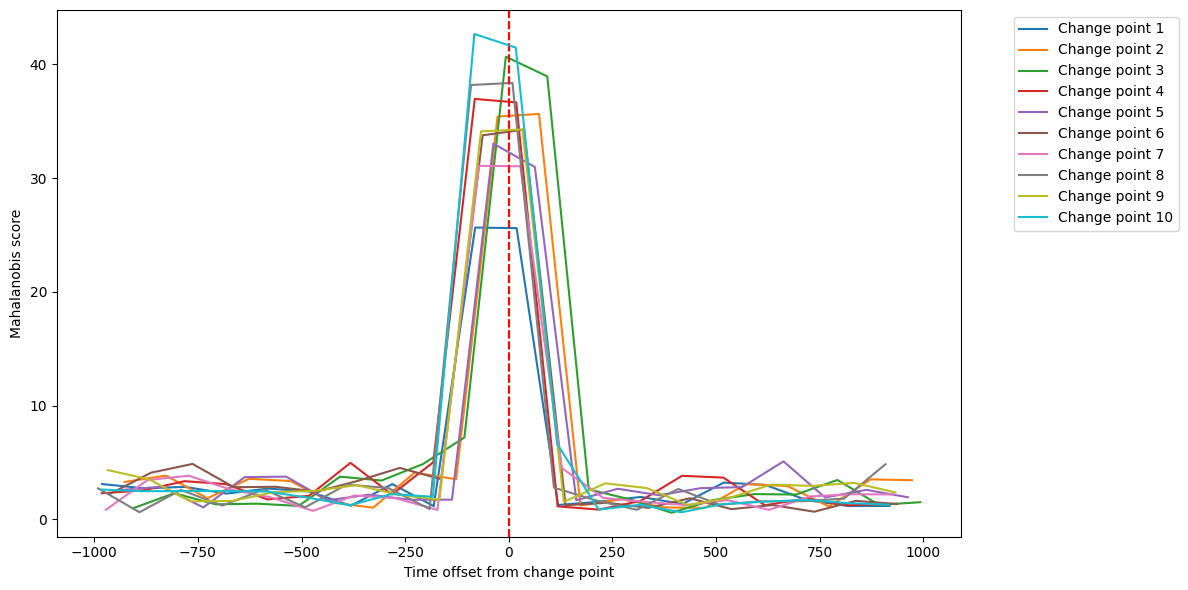

In [71]:
plt.figure(figsize=(12, 6))

for i in range(10):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores_mahal[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# w=100, s=10

In [72]:
WINDOW = 100
STEP = 10

timestamps = []
scores_mahal = []
all_features = []
feature_pairs = []  # Store which windows were compared

# First pass: Extract and store all features
window_features = []  # Store features for each window position
window_times = []

for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features_new_v5(left_window)
    right_feat, _ = extract_features_new_v5(right_window)

    # Store features
    window_features.append({
        'timestamp': t,
        'left_features': left_feat,
        'right_features': right_feat
    })

    # Collect for covariance matrix (all unique windows)
    all_features.append(left_feat)
    all_features.append(right_feat)

    # Store which features are paired together
    feature_pairs.append((len(window_features)-1, 'left', 'right'))

window_features = np.array(window_features, dtype=object)  # Keep as structured array
all_features = np.array(all_features)

# Compute covariance matrix (once)
cov = np.cov(all_features.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = pinv(cov)

# Second pass: Compute distances using precomputed features
timestamps = []
scores_mahal = []

for idx, pair in enumerate(window_features):
    left_feat = pair['left_features']
    right_feat = pair['right_features']
    t = pair['timestamp']

    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

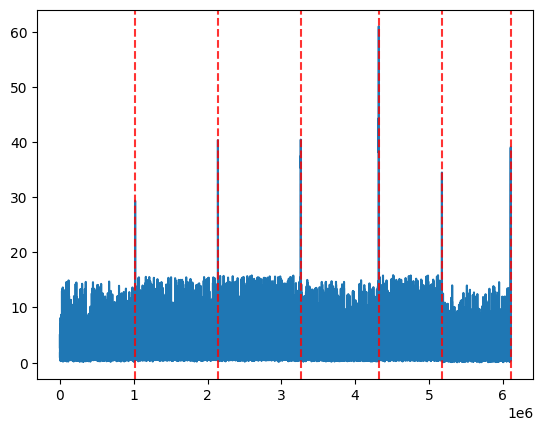

In [73]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## plot

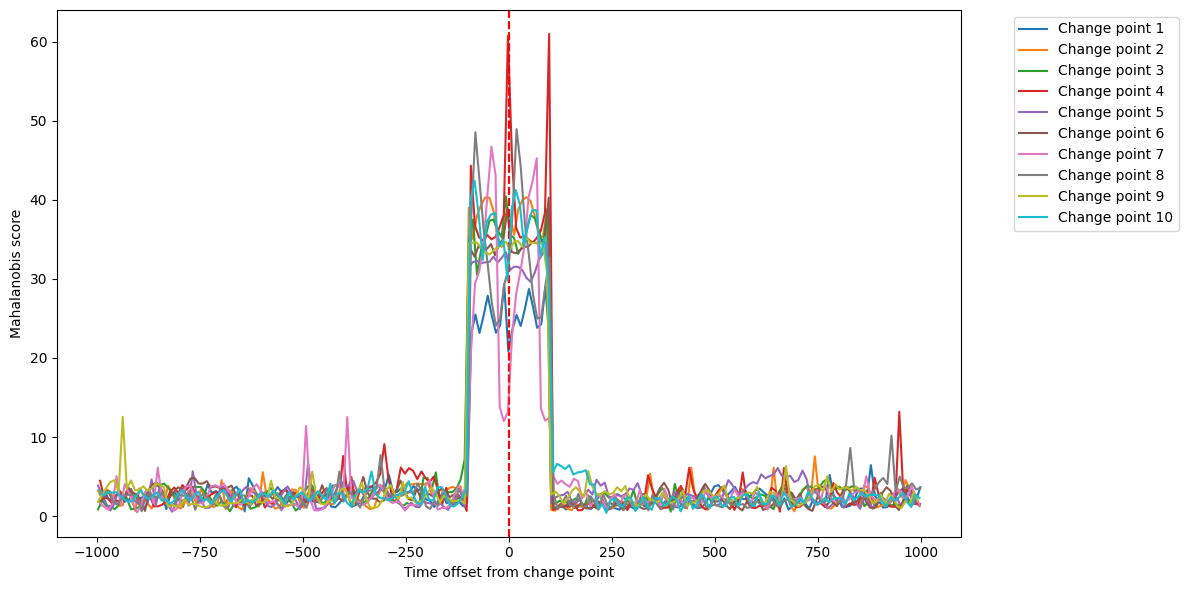

In [74]:
plt.figure(figsize=(12, 6))

for i in range(10):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores_mahal[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# w=50, s=10

In [75]:
WINDOW = 50
STEP = 10

timestamps = []
scores_mahal = []
all_features = []
feature_pairs = []  # Store which windows were compared

# First pass: Extract and store all features
window_features = []  # Store features for each window position
window_times = []

for t in range(WINDOW, len(data) - WINDOW, STEP):
    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features_new_v5(left_window)
    right_feat, _ = extract_features_new_v5(right_window)

    # Store features
    window_features.append({
        'timestamp': t,
        'left_features': left_feat,
        'right_features': right_feat
    })

    # Collect for covariance matrix (all unique windows)
    all_features.append(left_feat)
    all_features.append(right_feat)

    # Store which features are paired together
    feature_pairs.append((len(window_features)-1, 'left', 'right'))

window_features = np.array(window_features, dtype=object)  # Keep as structured array
all_features = np.array(all_features)

# Compute covariance matrix (once)
cov = np.cov(all_features.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = pinv(cov)

# Second pass: Compute distances using precomputed features
timestamps = []
scores_mahal = []

for idx, pair in enumerate(window_features):
    left_feat = pair['left_features']
    right_feat = pair['right_features']
    t = pair['timestamp']

    s_mahal = mahalanobis_distance(left_feat, right_feat, cov_inv)

    timestamps.append(t)
    scores_mahal.append(s_mahal)

timestamps = np.array(timestamps)
scores_mahal = np.array(scores_mahal)

## plot

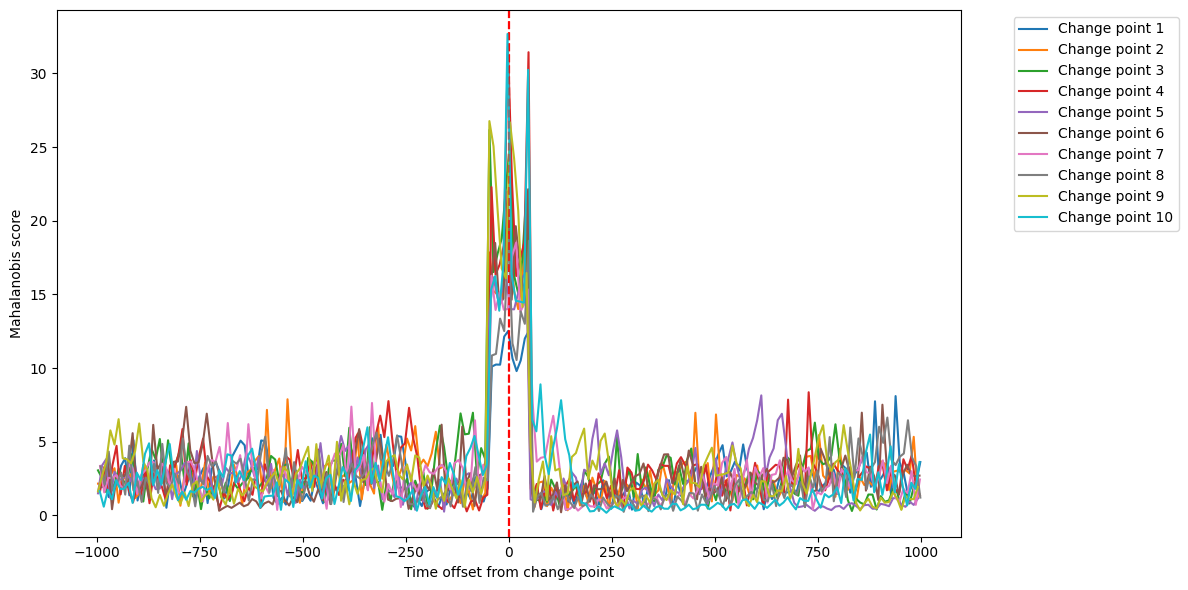

In [76]:
plt.figure(figsize=(12, 6))

for i in range(10):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores_mahal[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
half_range = 5000

relative_axis = np.arange(-half_range, half_range + 1, STEP)

all_curves = []

for cp in change_points:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()